<a href="https://colab.research.google.com/github/23aswathy/ASWATHY-G/blob/main/Bank_Telemarketing_finaleval_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import files
files.upload()

Saving bank_full.csv to bank_full.csv


{'bank_full.csv': b'age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y\r\n56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no\r\n57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no\r\n37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no\r\n40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no\r\n56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no\r\n45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no\r\n59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1

In [3]:
#Reading the dataset
data=pd.read_csv('bank_full.csv')

In [ ]:
#Input variables:
  # bank client data:
#age :age of customer
#job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
#marital : marital status (categorical: 'divorced','married','single','unknown')
#education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
#default: has credit in default? (categorical: 'no','yes','unknown')
#housing: has housing loan? (categorical: 'no','yes','unknown')
#loan: has personal loan? (categorical: 'no','yes','unknown')
#related with the last contact of the current campaign:
#contact: contact communication type
#month: last contact month of year
#day_of_week: last contact day of the week
#duration: last contact duration, in seconds (numeric)
#campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
#pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
#previous: number of contacts performed before this campaign and for this client (numeric)
#poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
#emp.var.rate: employment variation rate - quarterly indicator (numeric)
#cons.price.idx: consumer price index - monthly indicator (numeric)
#cons.conf.idx: consumer confidence index - monthly indicator (numeric)
#euribor3m: euribor 3 month rate - daily indicator (numeric)
#nr.employed: number of employees - quarterly indicator (numeric)
  Output variable :
# y - has the client subscribed a term deposit? (binary: "yes","no")




In [4]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [7]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
data.shape

(41188, 21)

In [9]:
data.nunique()

,0
age,78
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5


In [10]:
for a in list(data.columns):

    # get a list of unique values
    n = data[a].unique()

    # if number of unique values is less than 30, print the values. Otherwise print the number of unique values
    if len(n)<20:
        print(a)
        print(n)
    else:
        print(a + ': ' +str(len(n)) + ' unique values')


age: 78 unique values
job
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital
['married' 'single' 'divorced' 'unknown']
education
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default
['no' 'unknown' 'yes']
housing
['no' 'yes' 'unknown']
loan
['no' 'yes' 'unknown']
contact
['telephone' 'cellular']
month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week
['mon' 'tue' 'wed' 'thu' 'fri']
duration: 1544 unique values
campaign: 42 unique values
pdays: 27 unique values
previous
[0 1 2 3 4 5 6 7]
poutcome
['nonexistent' 'failure' 'success']
emp.var.rate
[ 1.1  1.4 -0.1 -0.2 -1.8 -2.9 -3.4 -3.  -1.7 -1.1]
cons.price.idx: 26 unique values
cons.conf.idx: 26 unique values
euribor3m: 316 unique values
nr.employed
[5191.  5228.1 5195.8 5176.3 5099.1 5076.2 5017.5 5023.5 5008.7 4991.6
 4963.6]
y
['no' 'ye

In [11]:
data.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [12]:
cat_columns = data.select_dtypes(include=['object']).columns
num_columns=data.select_dtypes(include=['int64','float64']).columns

In [13]:
cat_columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [14]:
num_columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [15]:
df=data[num_columns].corr()

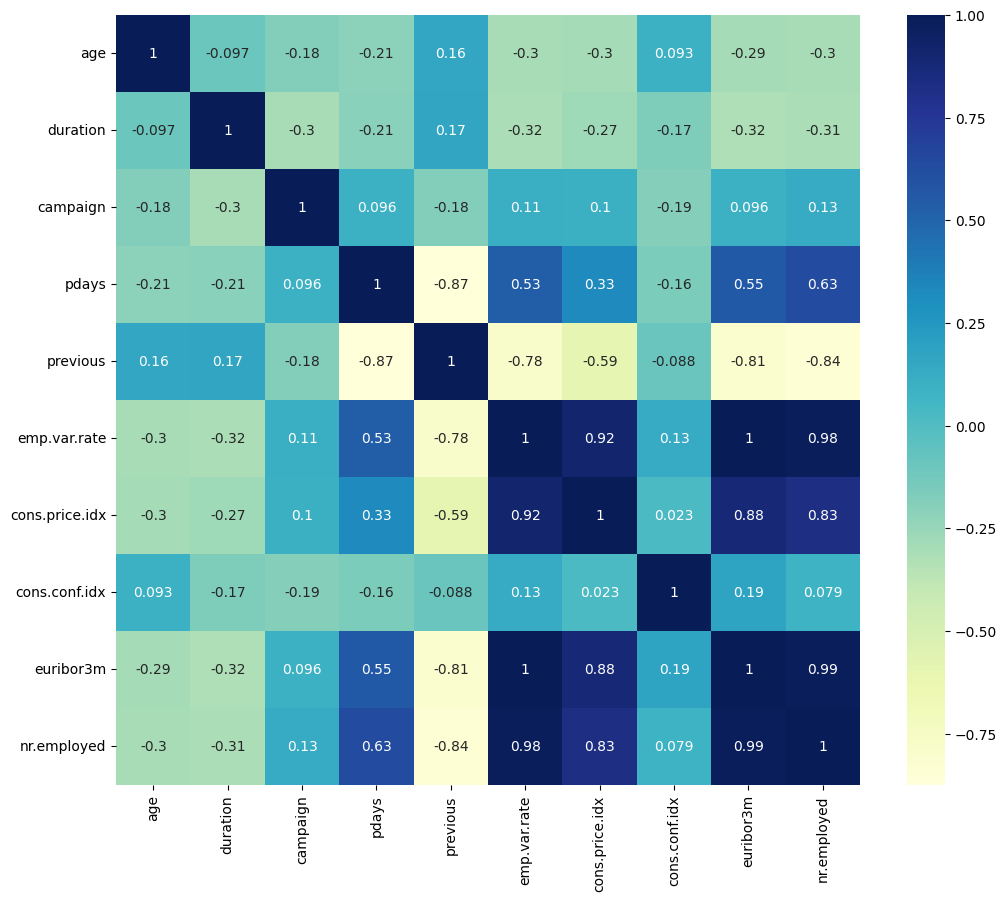

In [16]:
fig = plt.figure(figsize= (12, 10))
corr_df = sns.heatmap(df.corr(), cmap="YlGnBu", annot=True)

In [ ]:
#High correlation exists between emp.var.rate,euribor3m with nr.employed(0.98,0.99)
#High correlation exists between cons.price.idx and nr.employed(0.83)
#High correlation exists between cons.price.idx and nr.employed(0.83)
#High correlation exists between cons.price.idx and euribor3m(0.88)
#High correlation exists between emp.var.rate and cons.price.idx(0.92)



In [17]:
for i in data.columns:
    if data[i].dtypes == 'object':
        print(i)
        print('\n')
        print('the values are:')
        print(data[i].value_counts())
        print('\n\n')

job


the values are:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64



marital


the values are:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64



education


the values are:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64



default


the values are:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64



housing


the values are:
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64



loan




In [18]:
for i in data.columns:
    x = data[i].value_counts()
    print(data[i].value_counts())

age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
91       2
98       2
95       1
87       1
94       1
Name: count, Length: 78, dtype: int64
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count, 

In [19]:
def countplot(label, dataset):
  plt.figure(figsize=(15,10))
  Y = data[label]
  total = len(Y)*1.
  ax=sns.countplot(x=label, data=dataset)
  for p in ax.patches:
    ax.annotate('{:.1f}%'.format(100*p.get_height()/total), (p.get_x()+0.1, p.get_height()+5))

  #put 11 ticks (therefore 10 steps), from 0 to the total number of rows in the dataframe
  ax.yaxis.set_ticks(np.linspace(0, total, 11))
  #adjust the ticklabel to the desired format, without changing the position of the ticks.
  ax.set_yticklabels(map('{:.1f}%'.format, 100*ax.yaxis.get_majorticklocs()/total))
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
  # ax.legend(labels=["no","yes"])
  plt.show()

In [20]:
def countplot_withY(label, dataset):
  plt.figure(figsize=(20,10))
  Y = data[label]
  total = len(Y)*1.
  ax=sns.countplot(x=label, data=dataset, hue="y")
  for p in ax.patches:
    ax.annotate('{:.1f}%'.format(100*p.get_height()/total), (p.get_x()+0.1, p.get_height()+5))

  #put 11 ticks (therefore 10 steps), from 0 to the total number of rows in the dataframe
  ax.yaxis.set_ticks(np.linspace(0, total, 11))
  #adjust the ticklabel to the desired format, without changing the position of the ticks.
    # ax.legend(labels=["no","yes"])
  plt.show()

<ipython-input-19-72ee747e2f05>:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


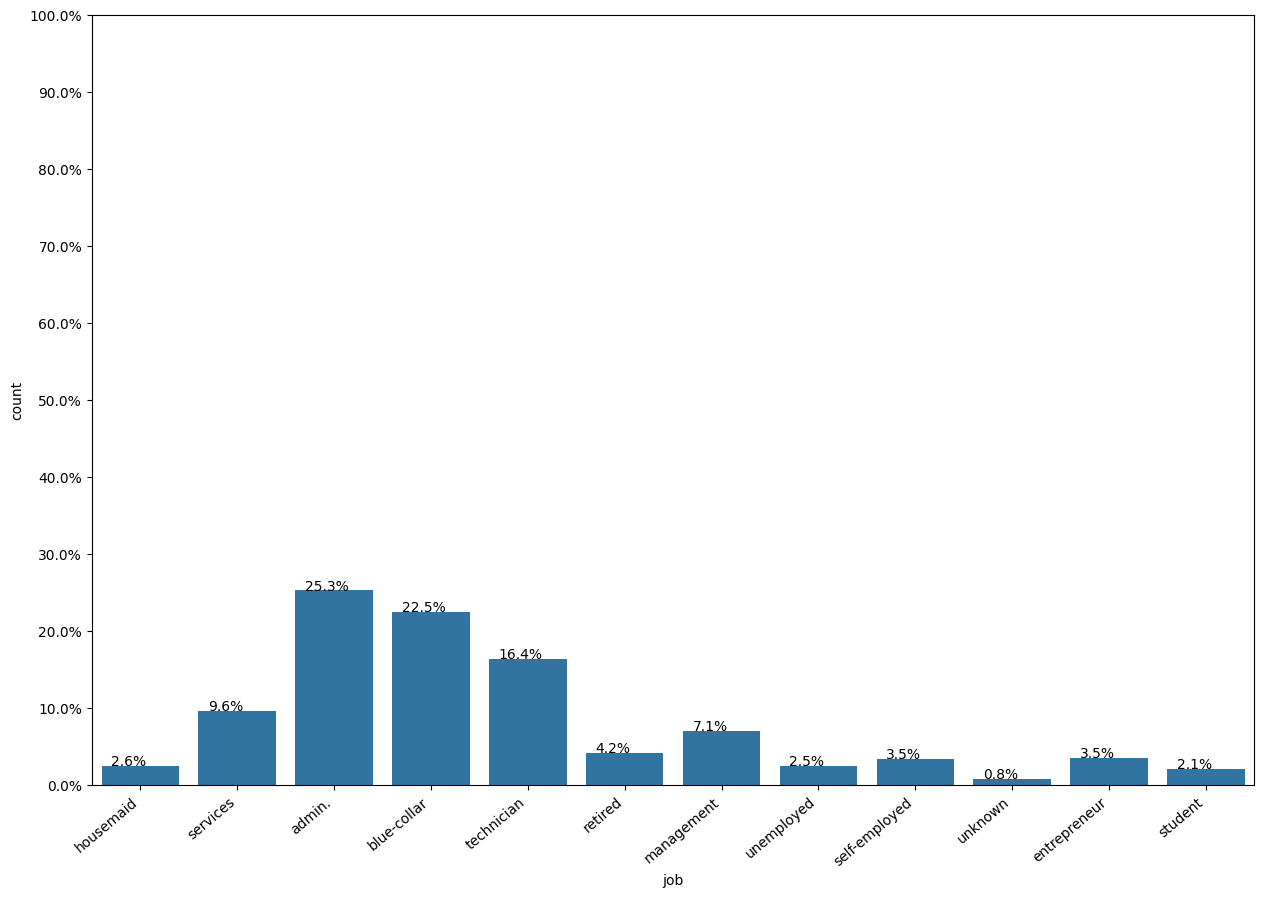

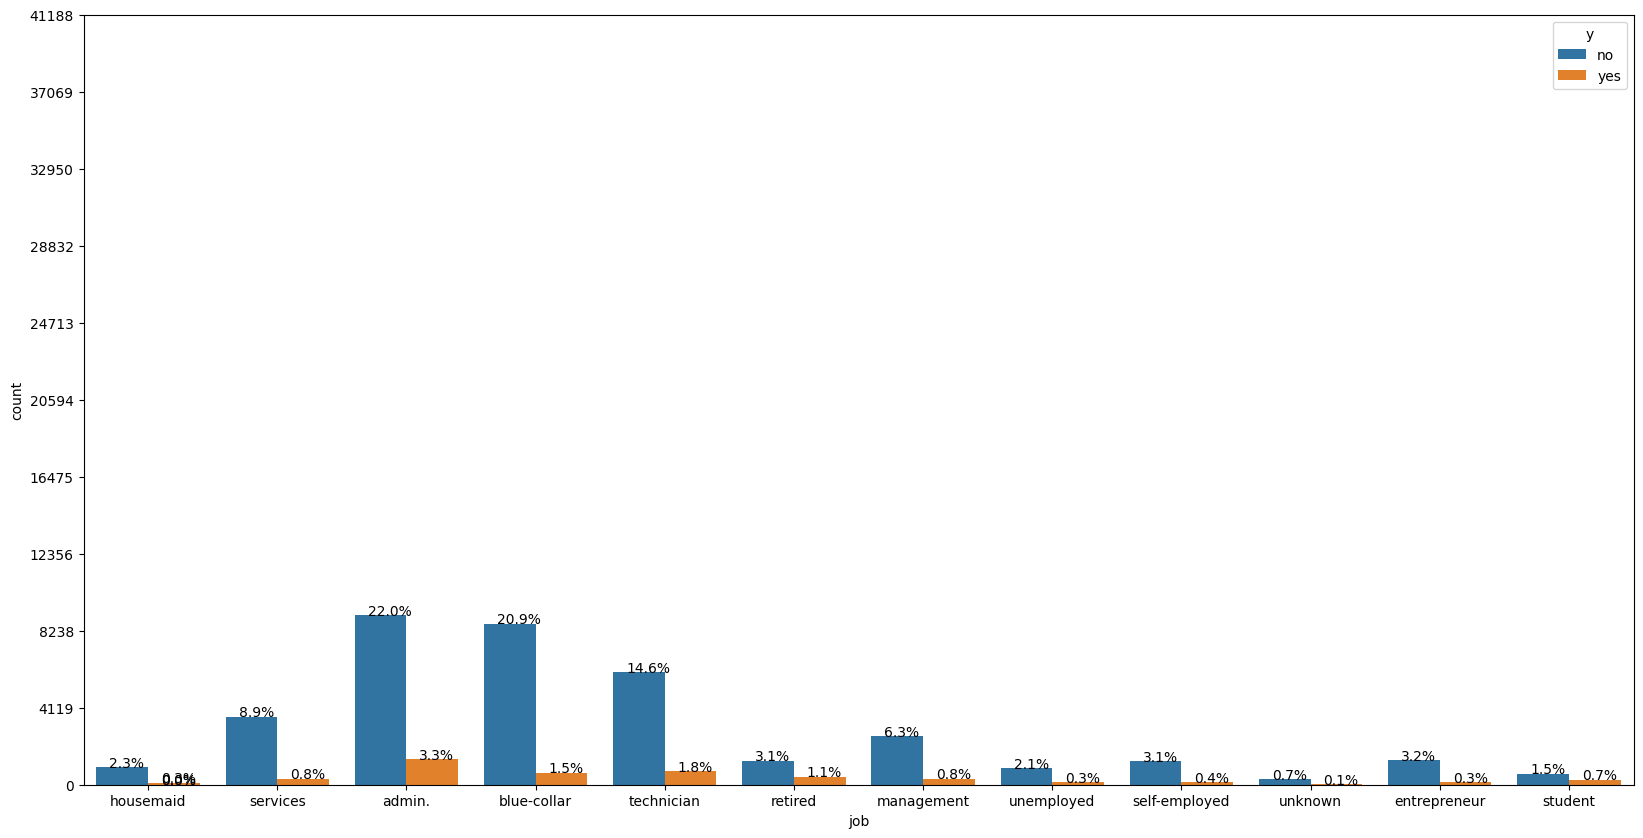

<ipython-input-19-72ee747e2f05>:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


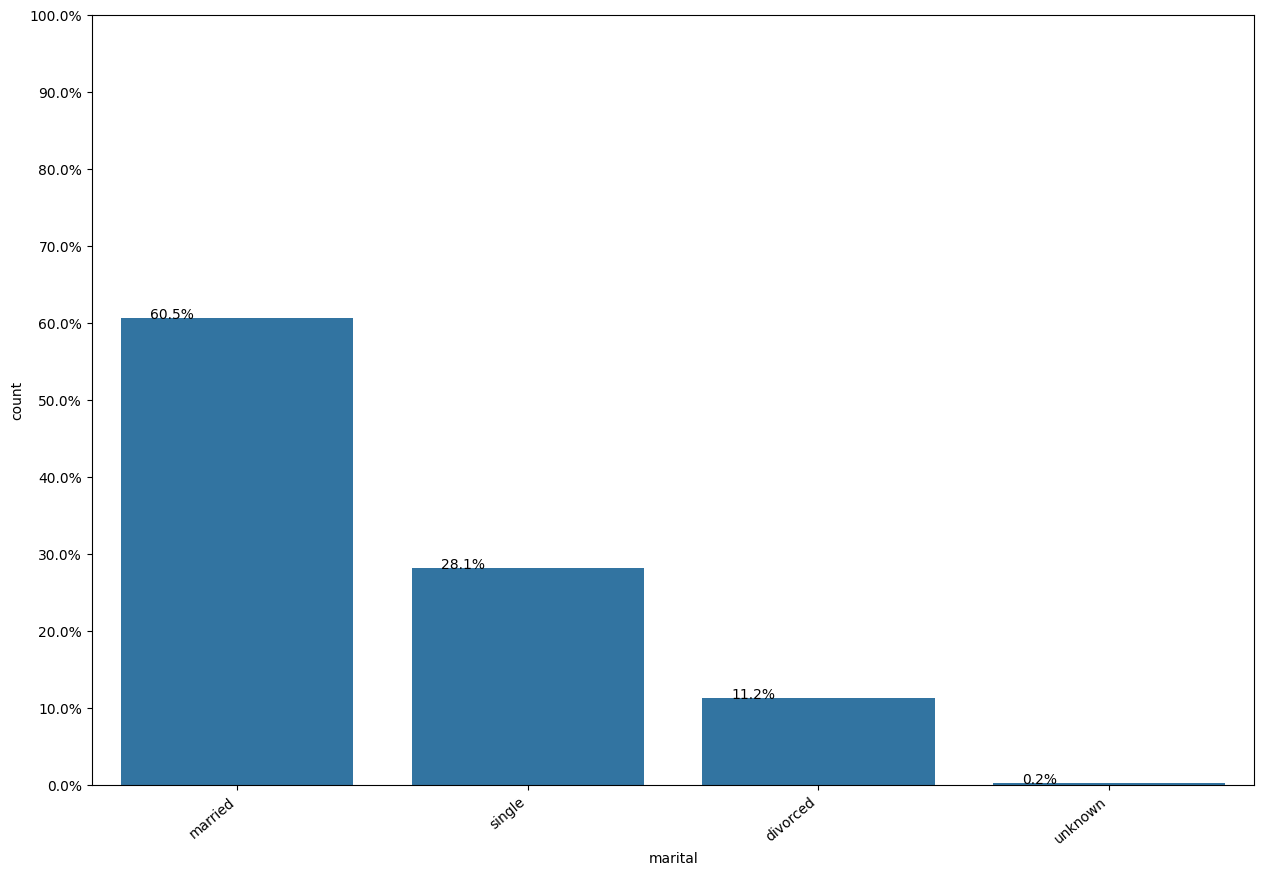

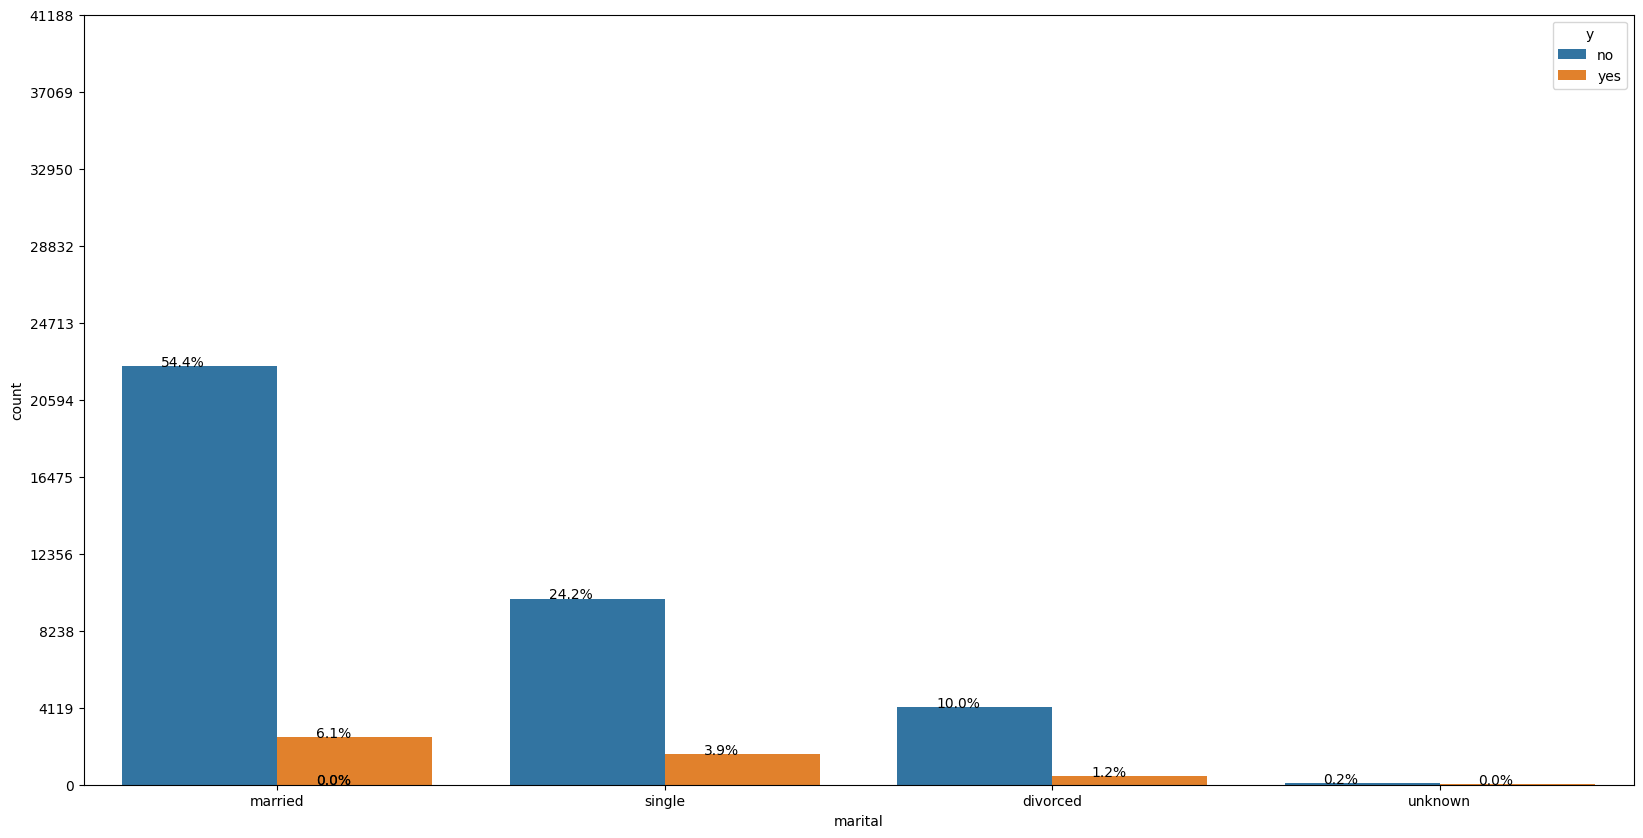

In [21]:
countplot("job", data)
countplot_withY("job", data)
countplot("marital", data)
countplot_withY("marital", data)

<ipython-input-19-72ee747e2f05>:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


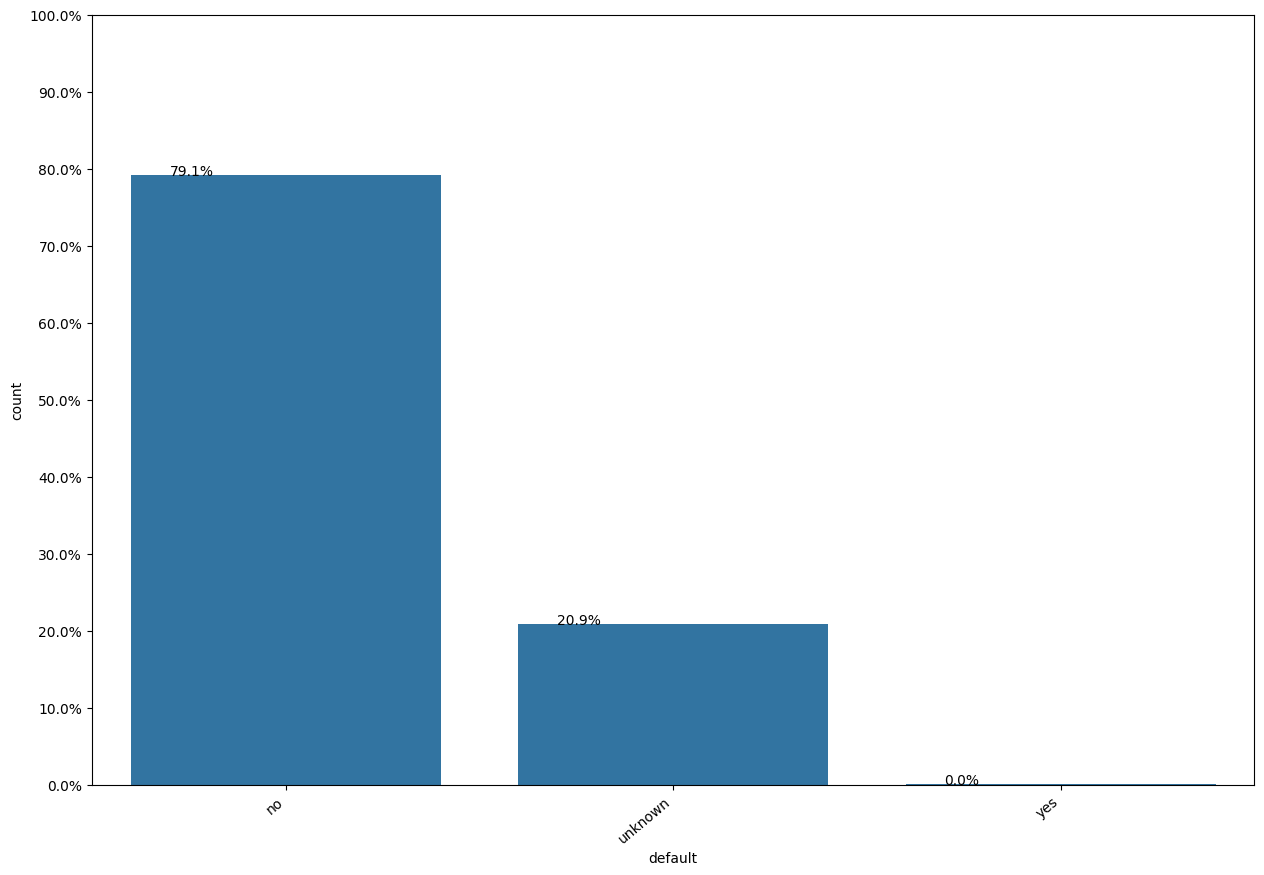

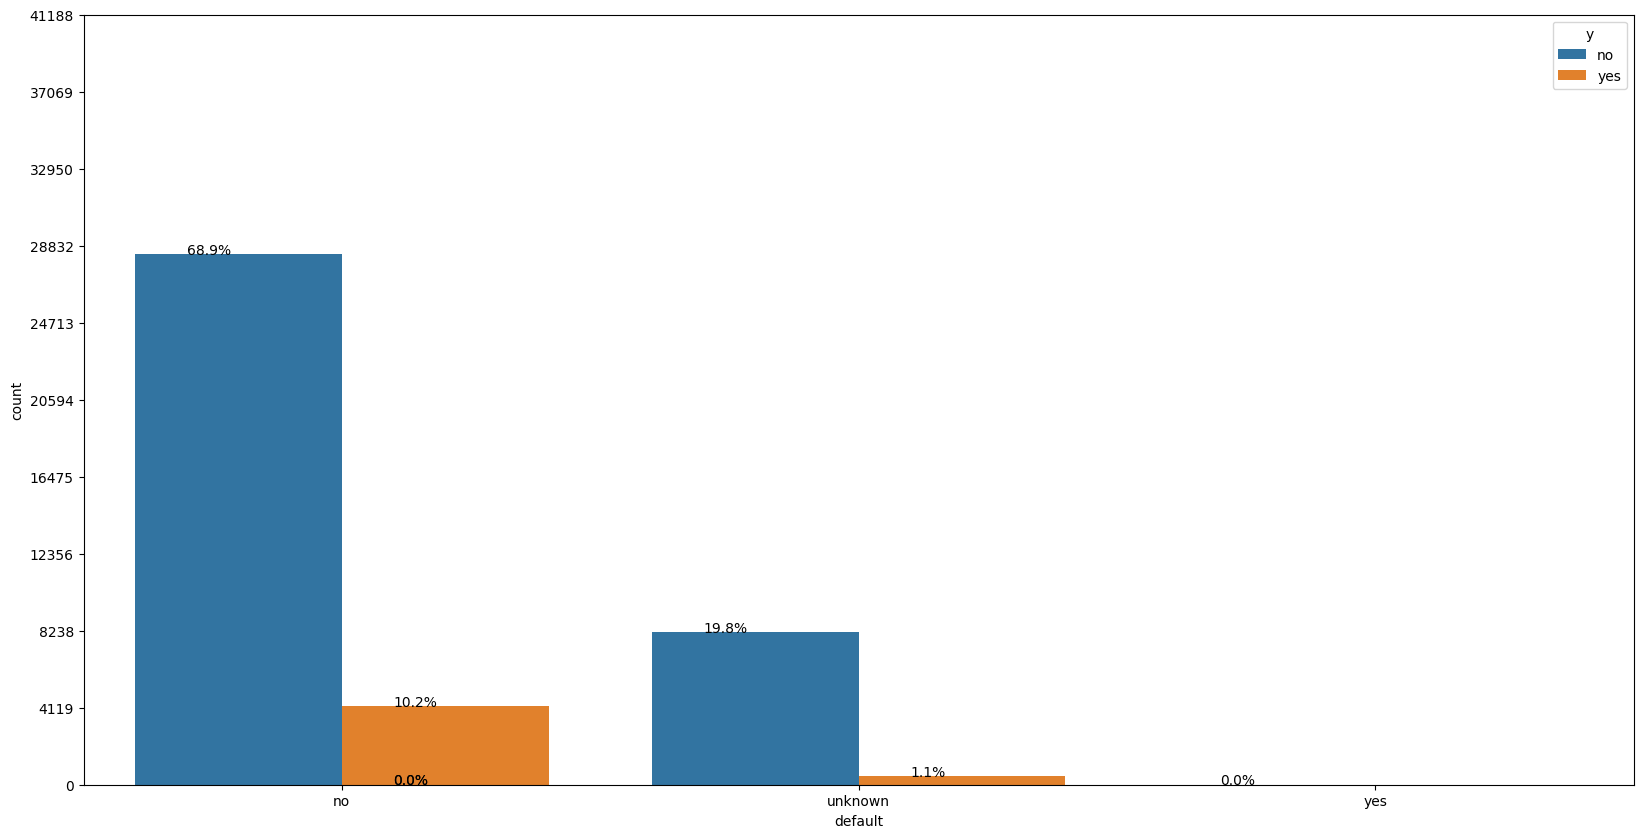

In [22]:
countplot("default", data)
countplot_withY("default", data)

<ipython-input-19-72ee747e2f05>:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


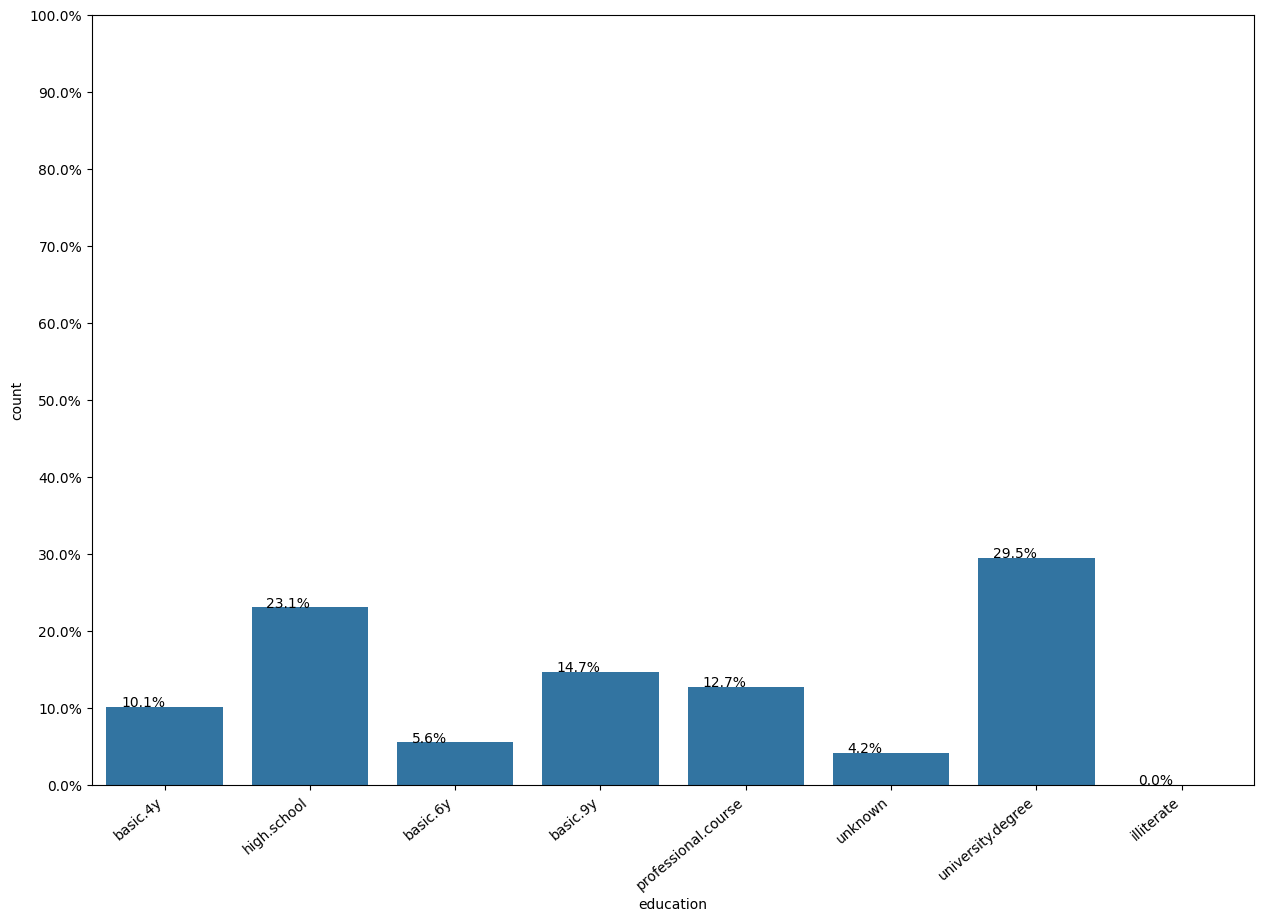

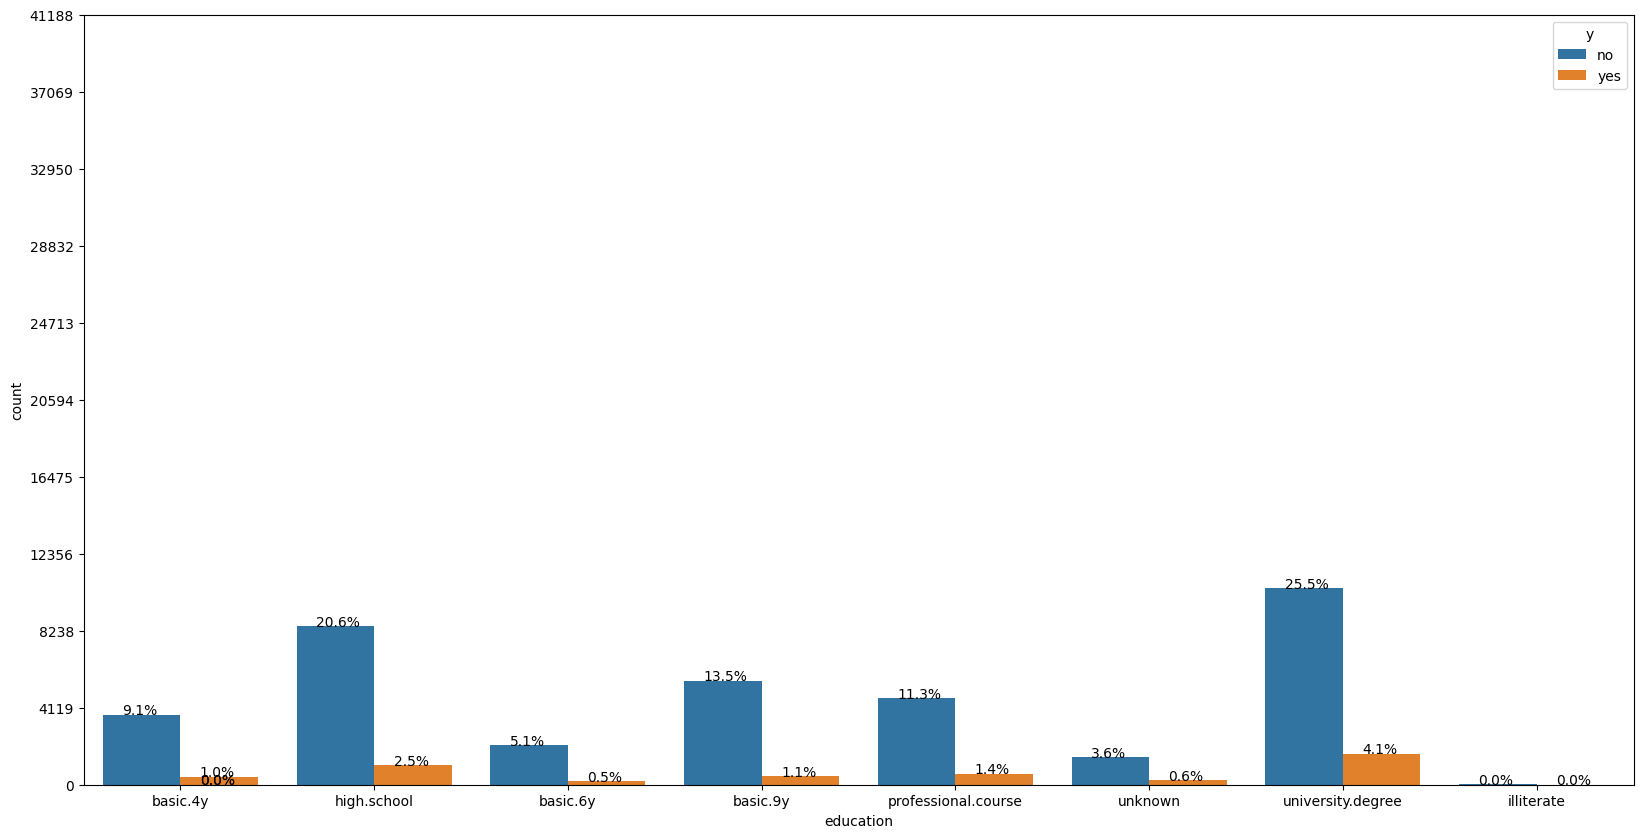

In [23]:
countplot("education",data)
countplot_withY("education",data)

<ipython-input-19-72ee747e2f05>:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


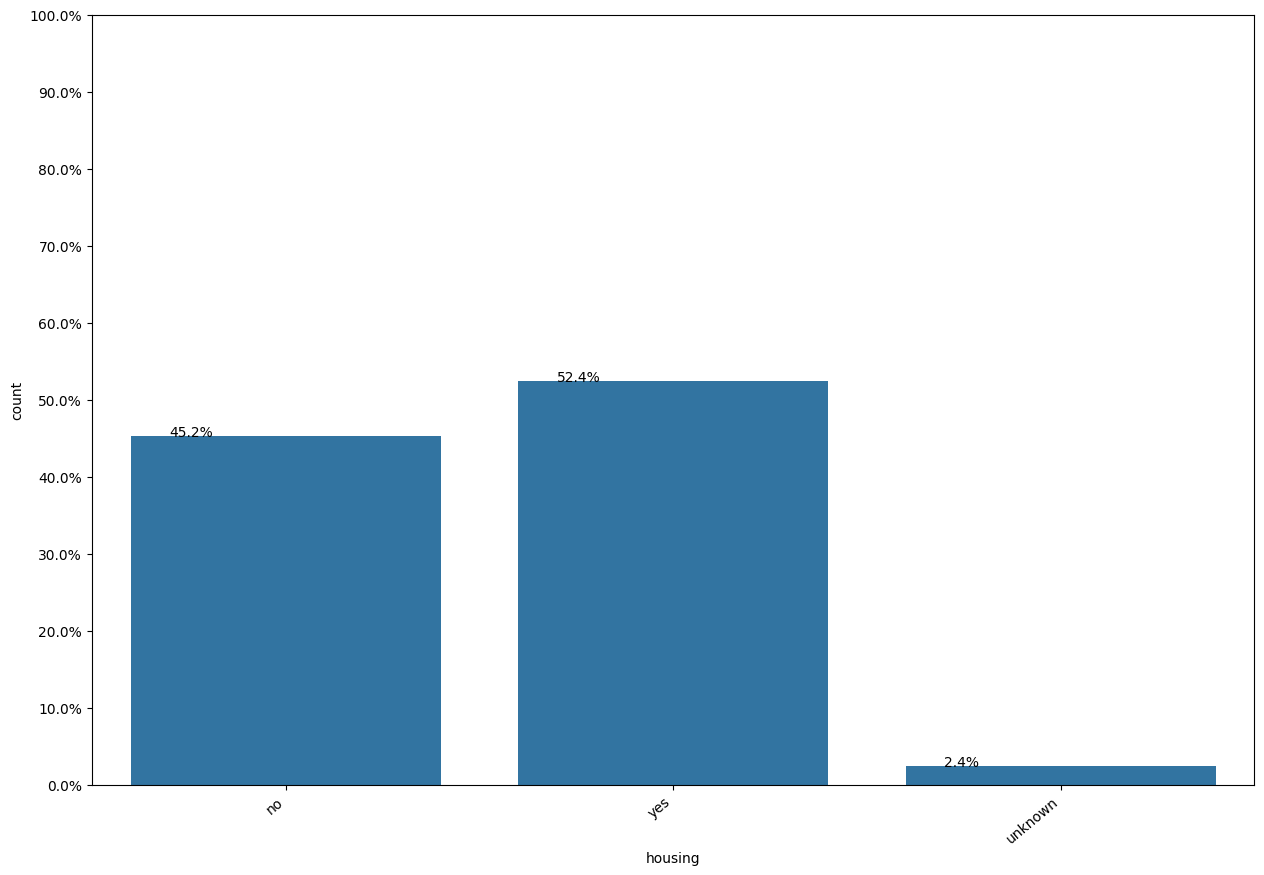

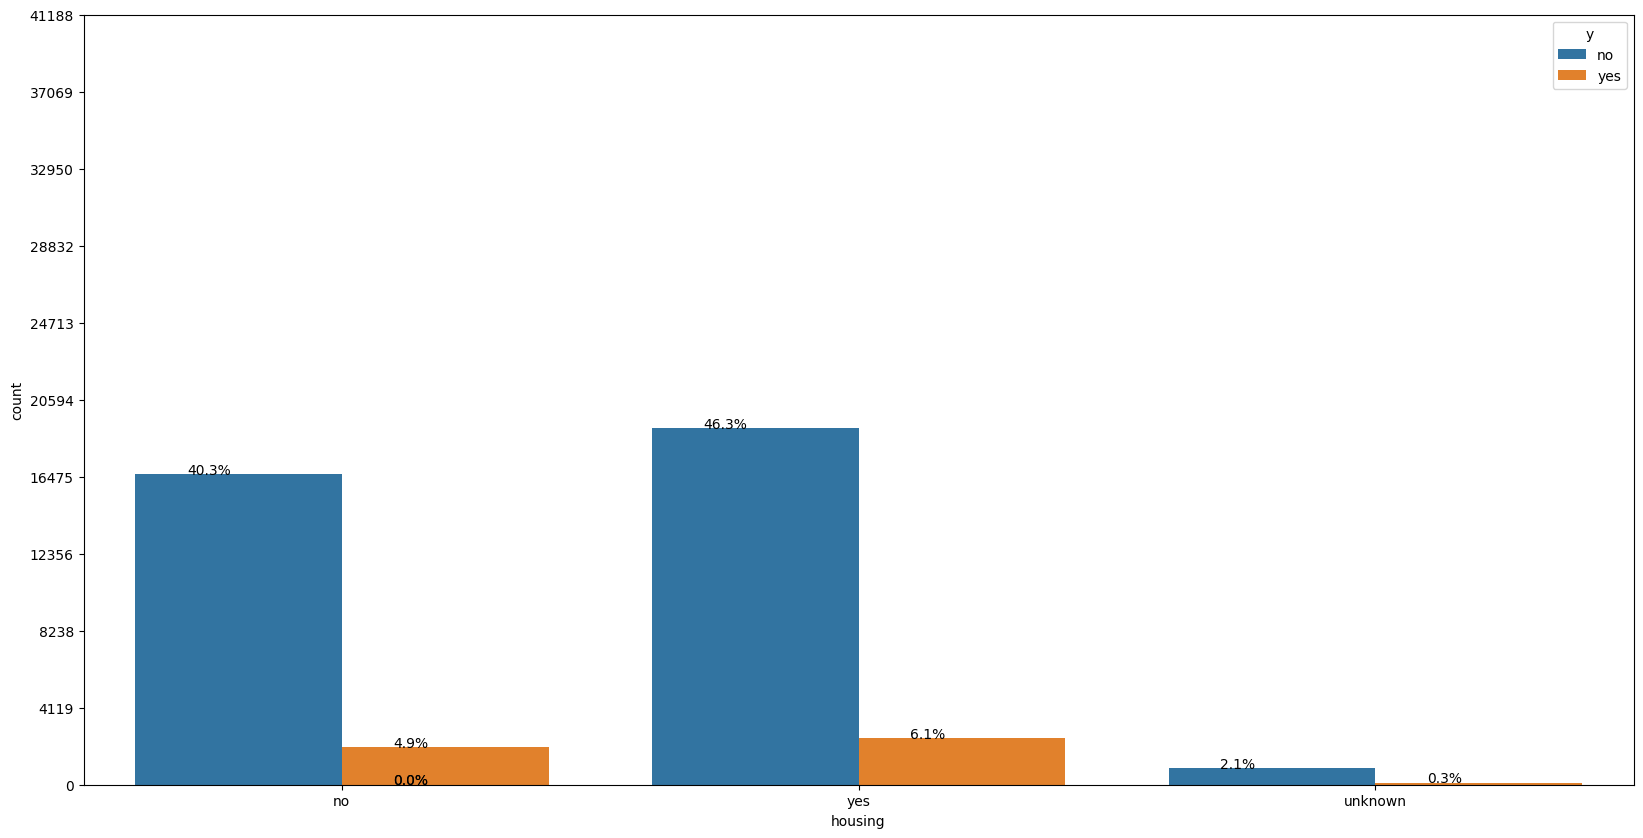

In [24]:
countplot("housing", data)
countplot_withY("housing", data)

<ipython-input-19-72ee747e2f05>:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


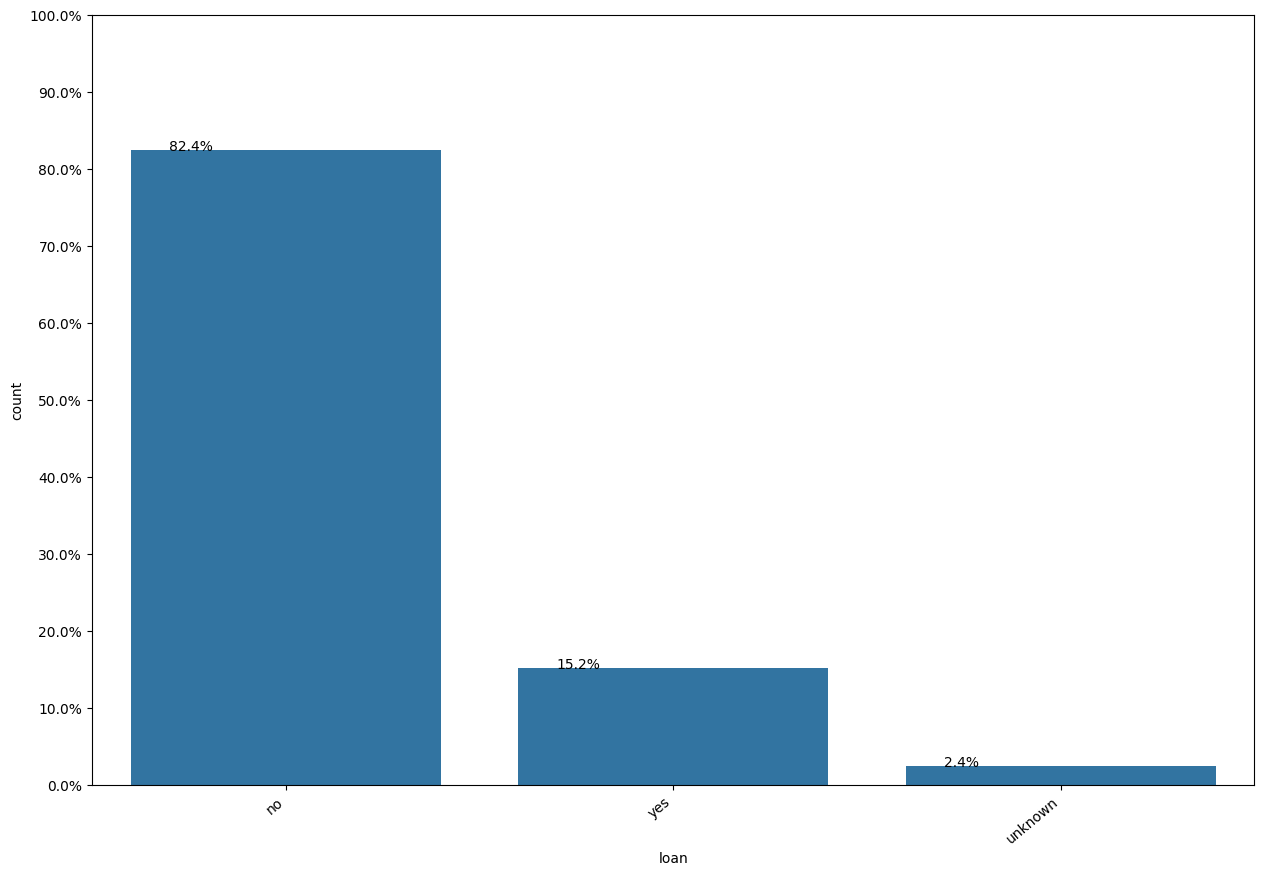

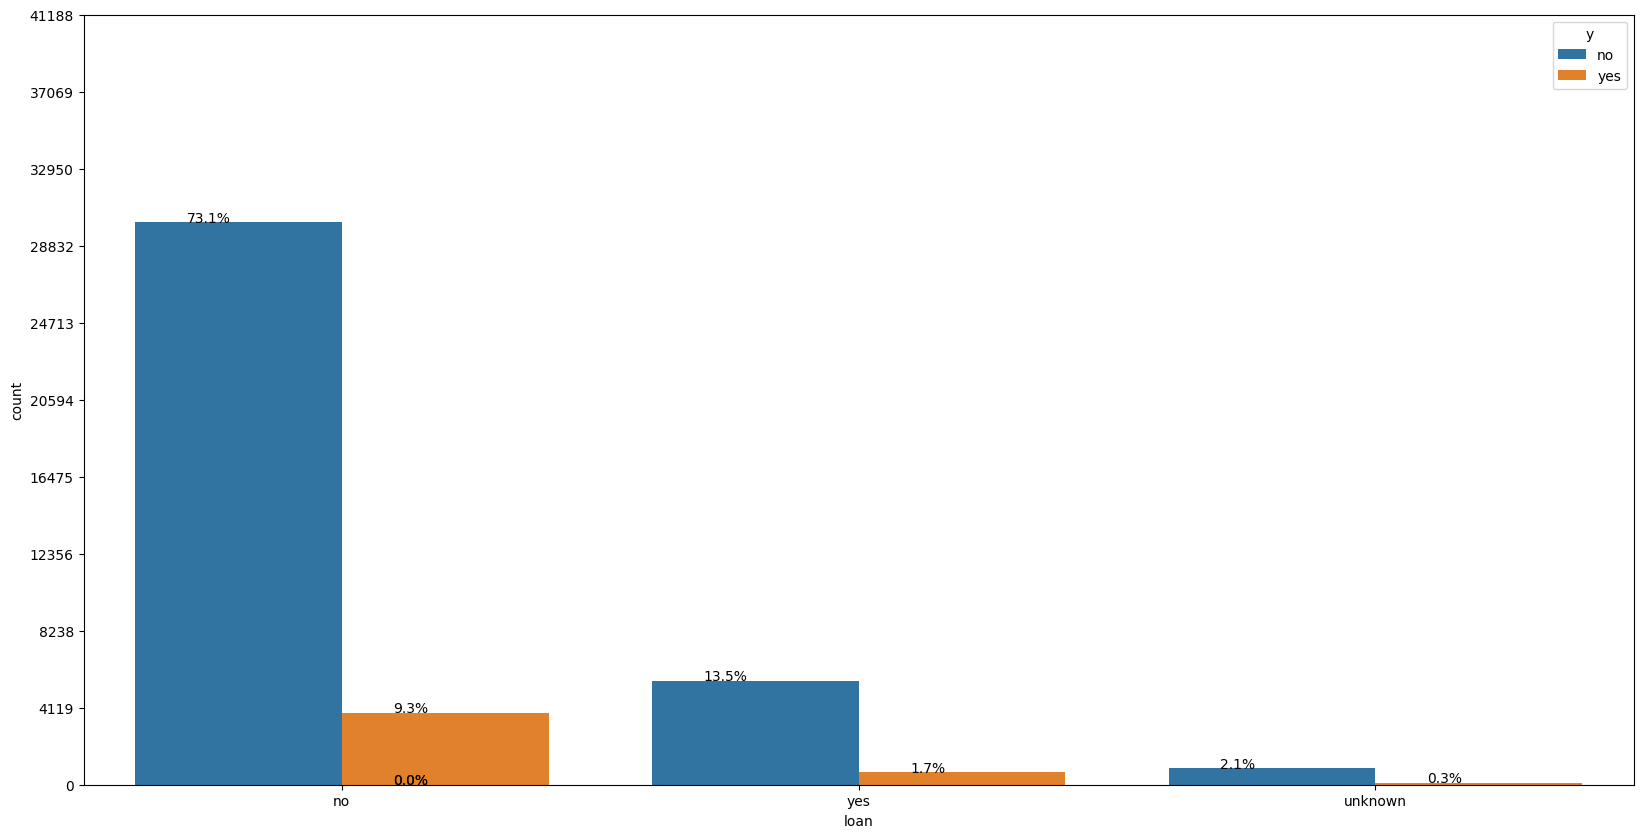

In [25]:
countplot("loan", data)
countplot_withY("loan", data)

<ipython-input-19-72ee747e2f05>:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


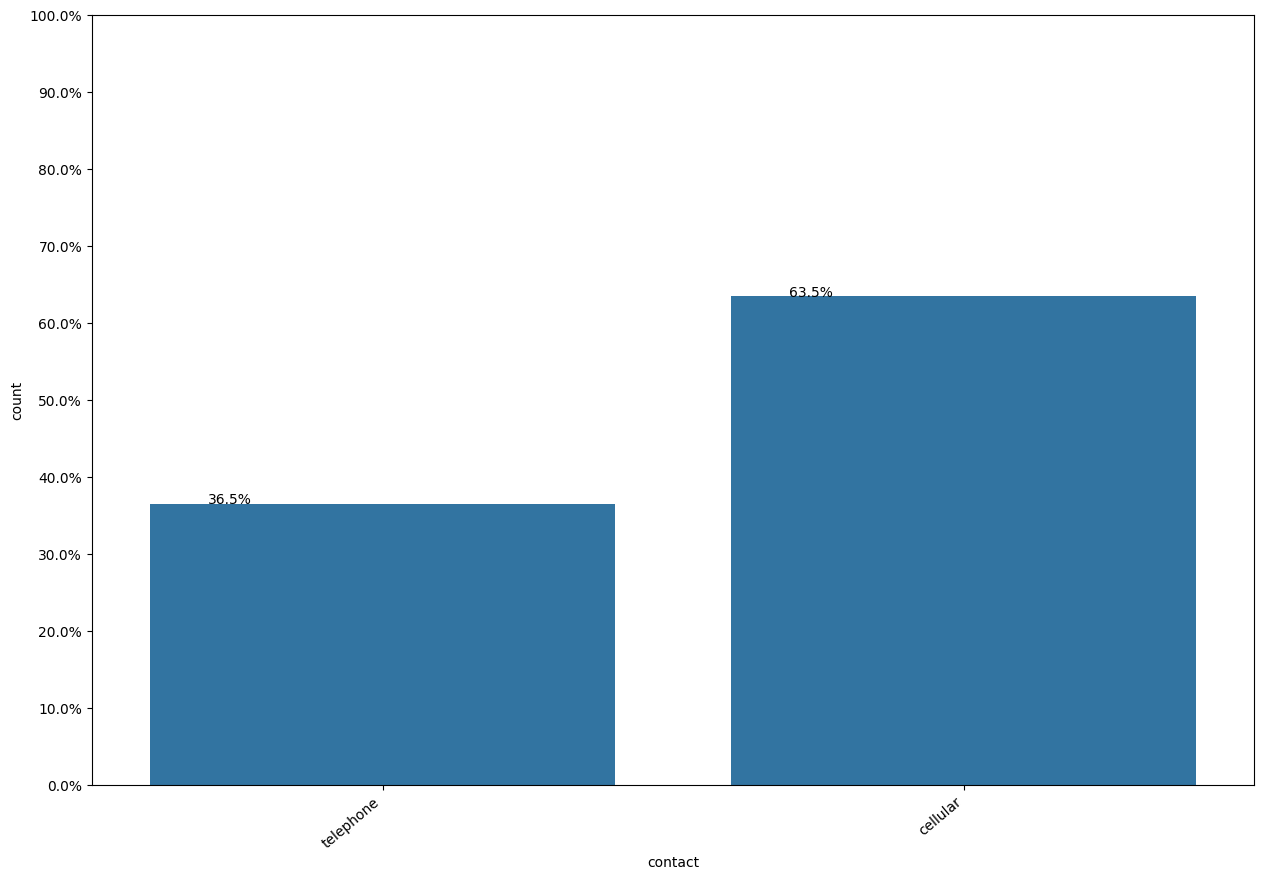

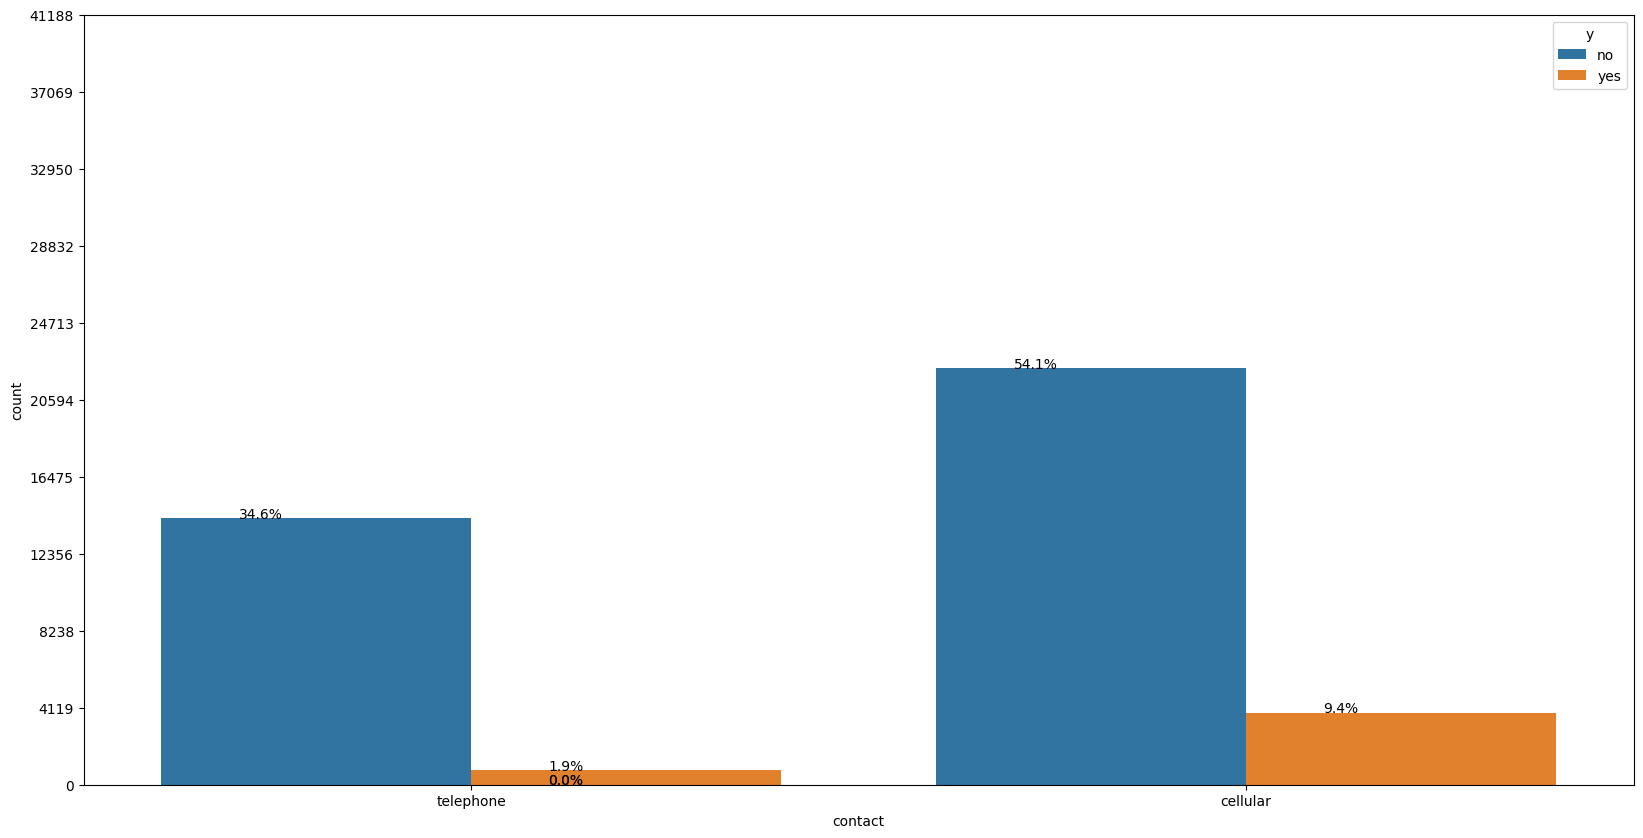

In [26]:
countplot("contact", data)
countplot_withY("contact", data)

<ipython-input-19-72ee747e2f05>:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


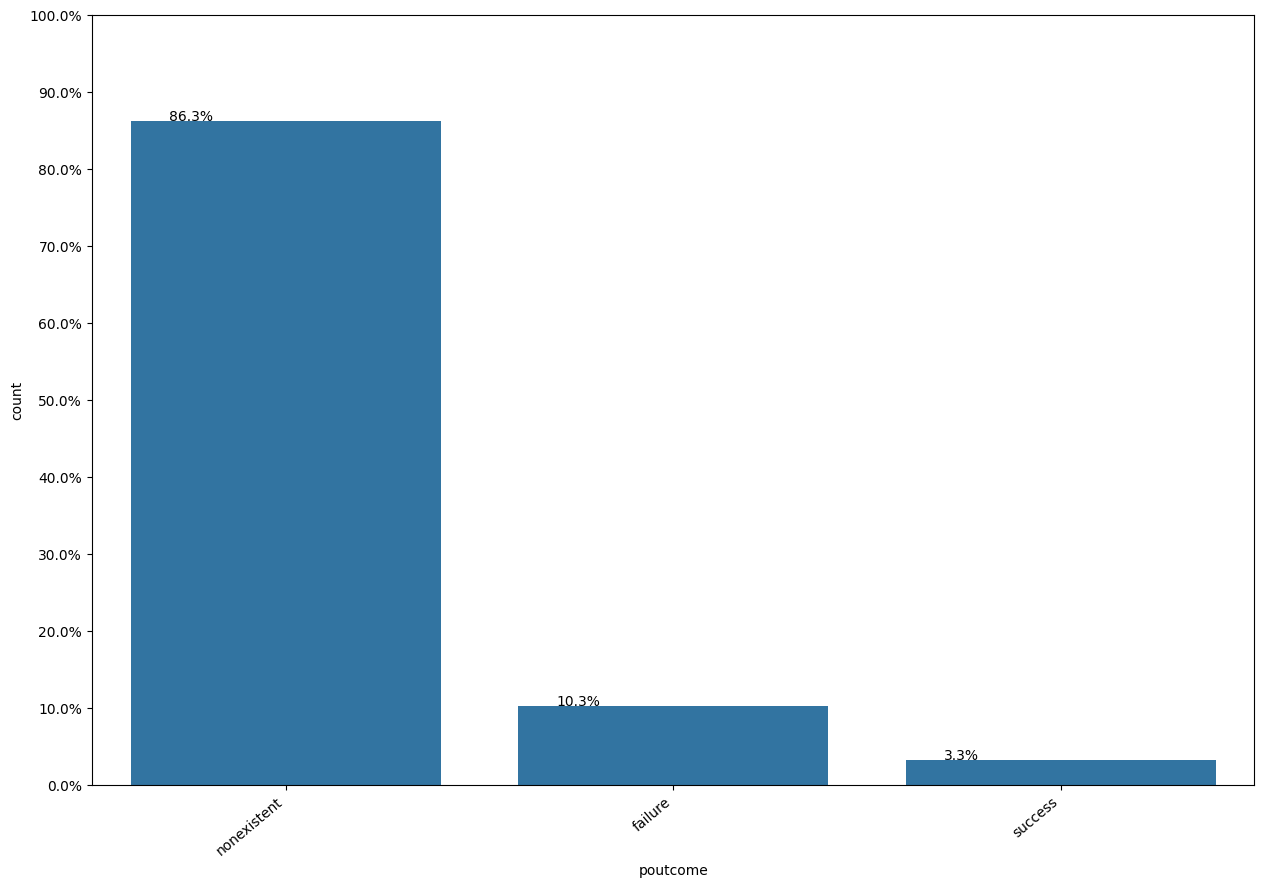

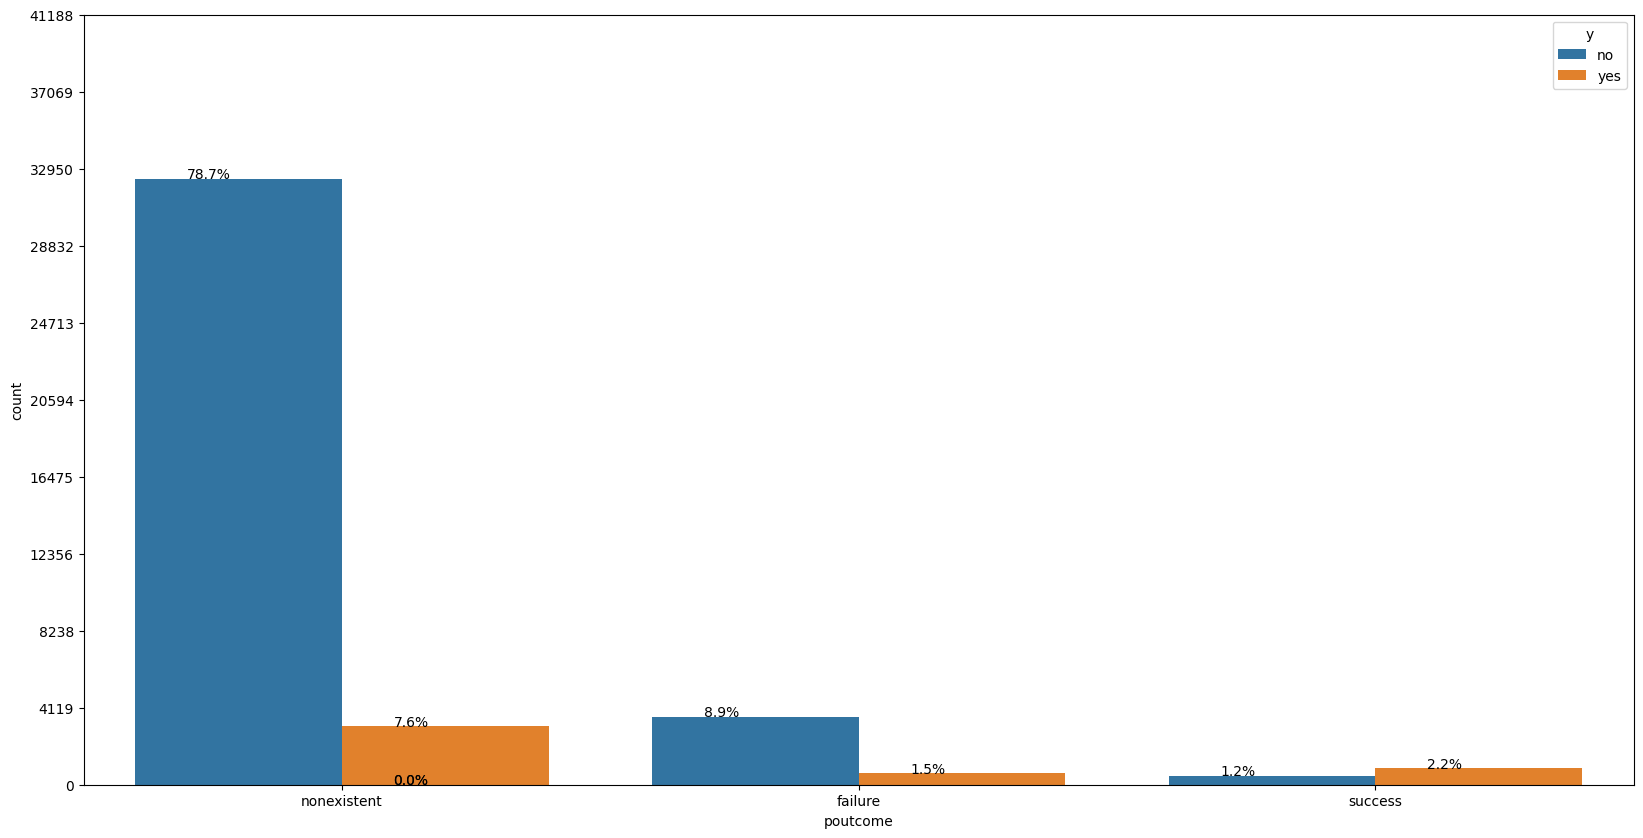

In [27]:
countplot("poutcome", data)
countplot_withY("poutcome", data)

<ipython-input-28-2fd56025d666>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["age"])


<Axes: xlabel='age', ylabel='Density'>

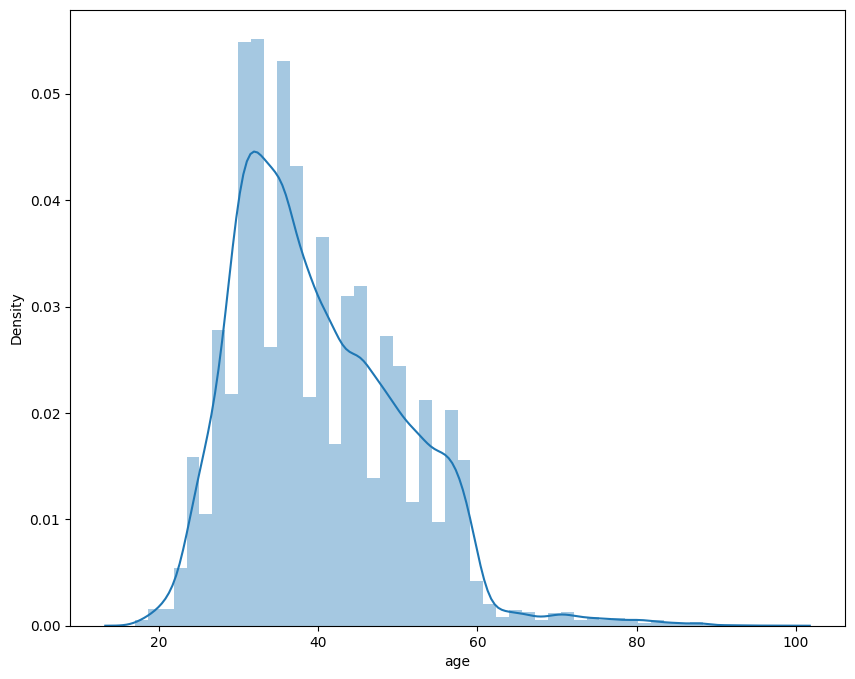

In [28]:
plt.figure(figsize=(10,8))
sns.distplot(data["age"])

<ipython-input-29-edea28d9effd>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["duration"])


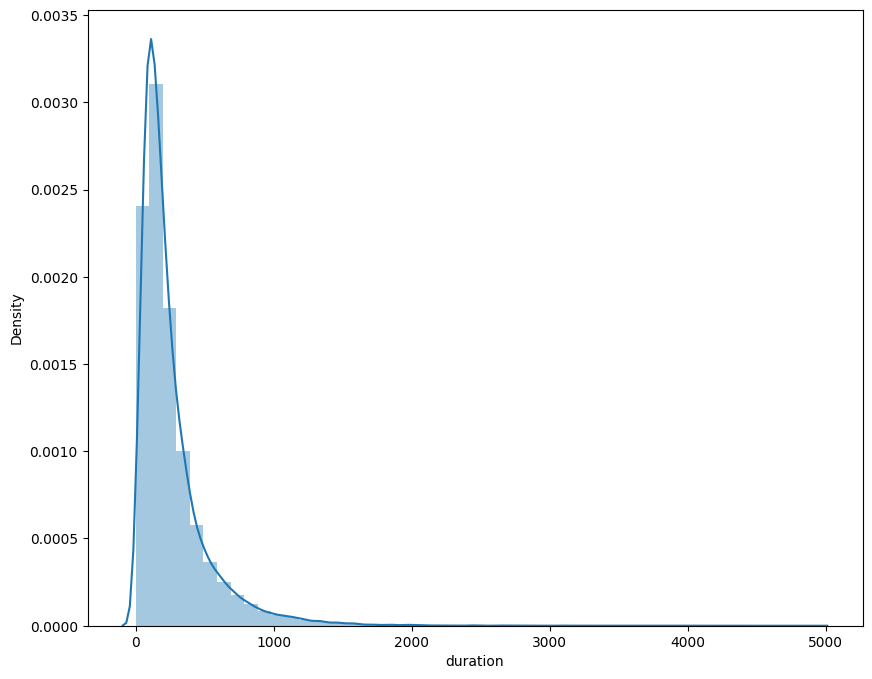

In [29]:
plt.figure(figsize=(10,8))
sns.distplot(data["duration"])
plt.show()


<ipython-input-30-cef63818b483>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["pdays"])


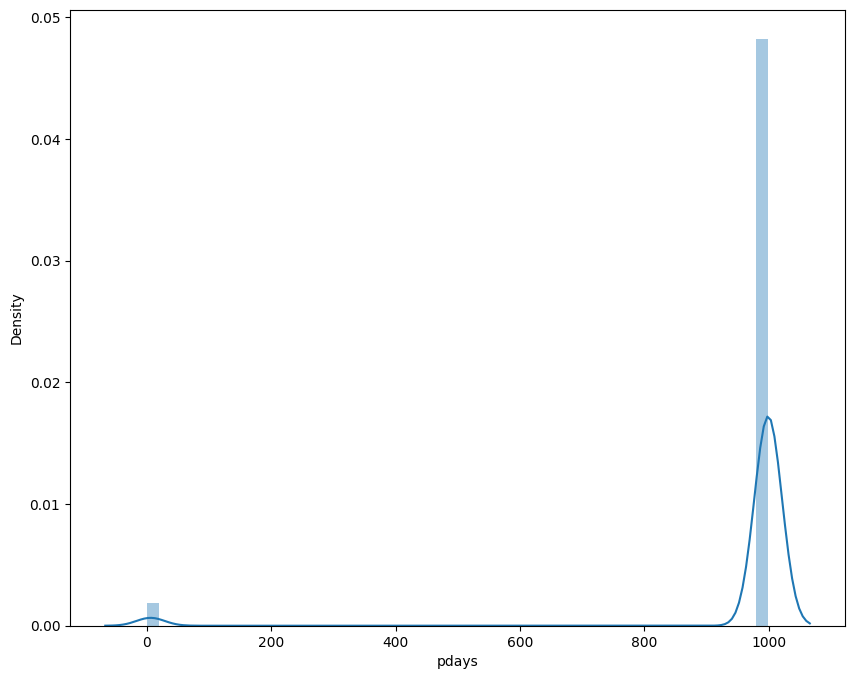

In [30]:
plt.figure(figsize=(10,8))
sns.distplot(data["pdays"])
plt.show()

<ipython-input-31-c0e3ad0dfdc3>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["euribor3m"])


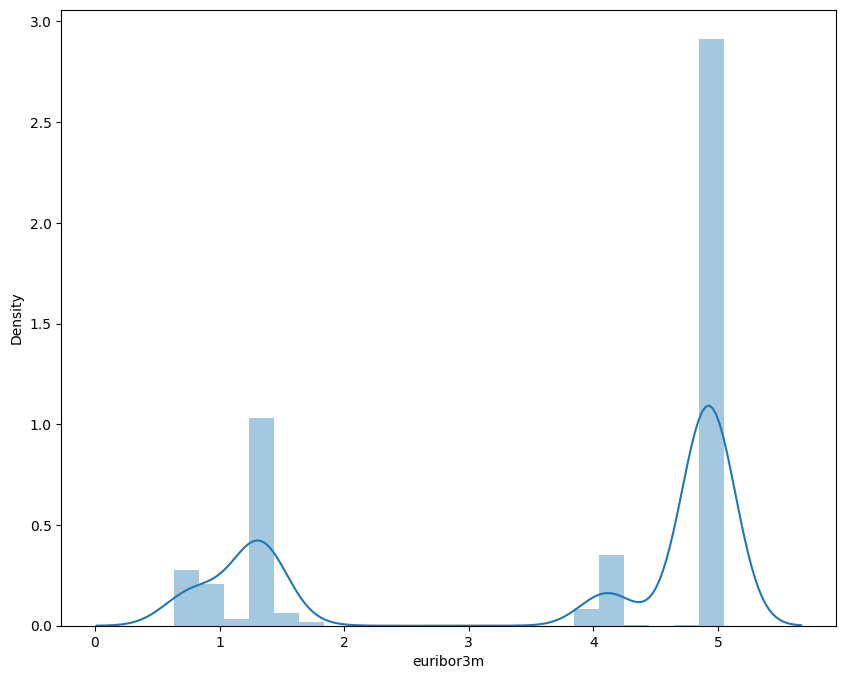

In [31]:
plt.figure(figsize=(10,8))
sns.distplot(data["euribor3m"])
plt.show()

<ipython-input-32-bc8da2b9b5c5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["nr.employed"])


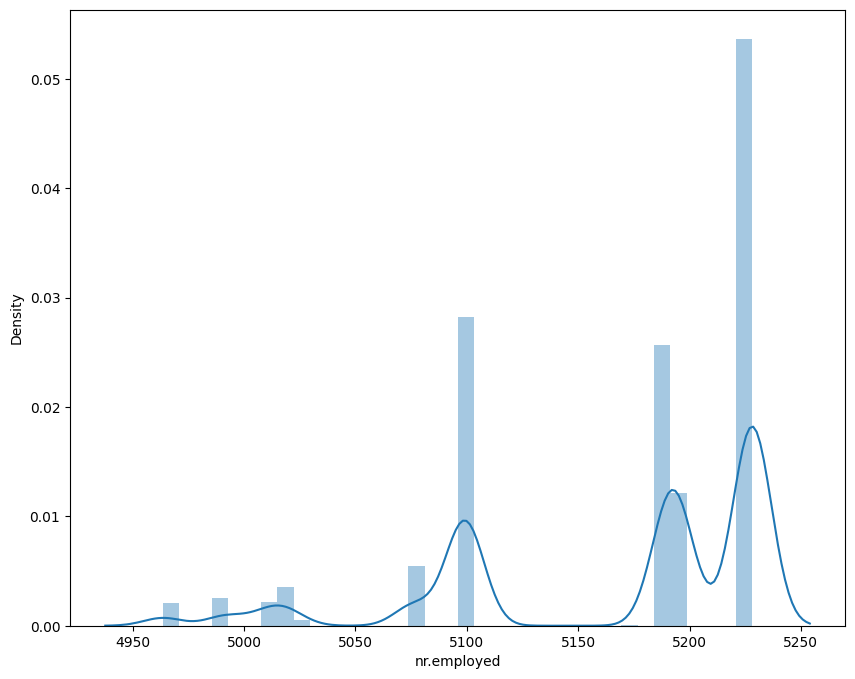

In [32]:
plt.figure(figsize=(10,8))
sns.distplot(data["nr.employed"])
plt.show()

In [ ]:
Findings
#Admin job people subscribe to the term deposit more.
#Housemaid category subscribe the least
#Married people ,majority do not subscrie the term deposit.
#Degree holders are the majority subscribers.
#Housing loan customers are approached more and there is no increase towards subscribtion.
#For those who have no personal loan had subscribed to some extent than personal loan holders.
#Month of May and day Thursday. had largest number of calls happened and subsription is high.
#Previous outcome success rate was very less

In [ ]:
#Data Preprocessing

In [33]:
data_dup = data[data.duplicated(keep="last")]
data_dup


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20072,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20531,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25183,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [34]:
df2=data.drop_duplicates()

In [35]:
df2.shape

(41176, 21)

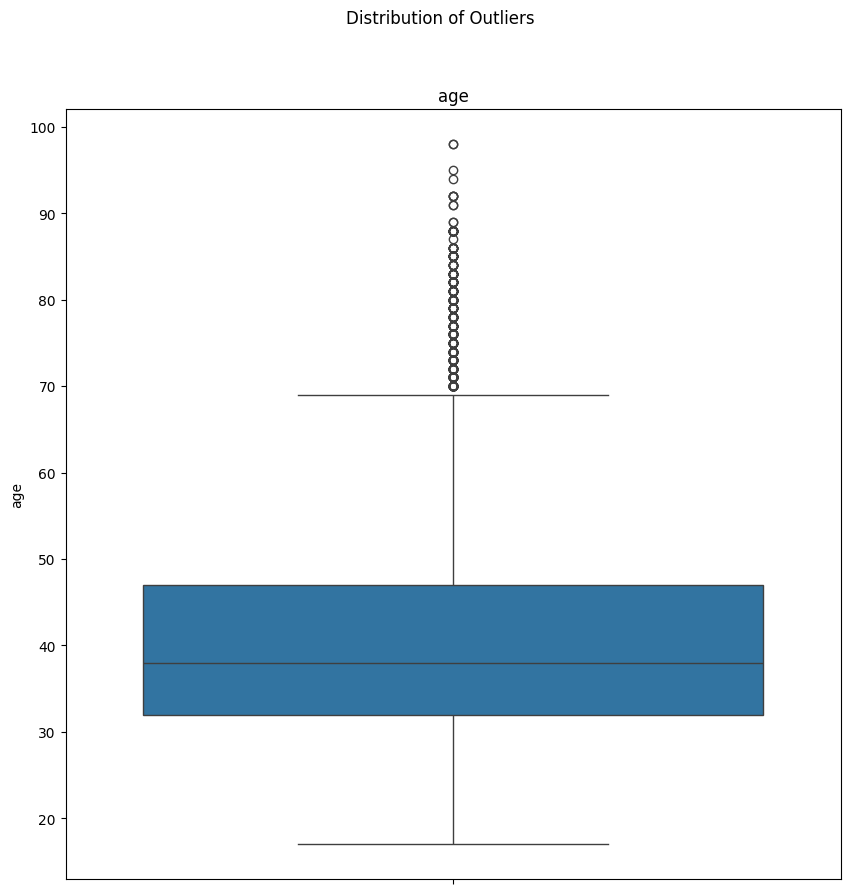

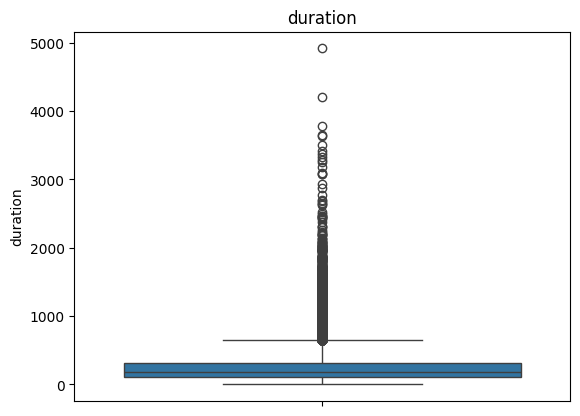

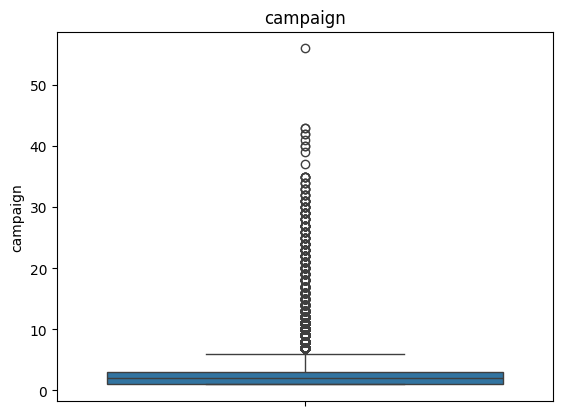

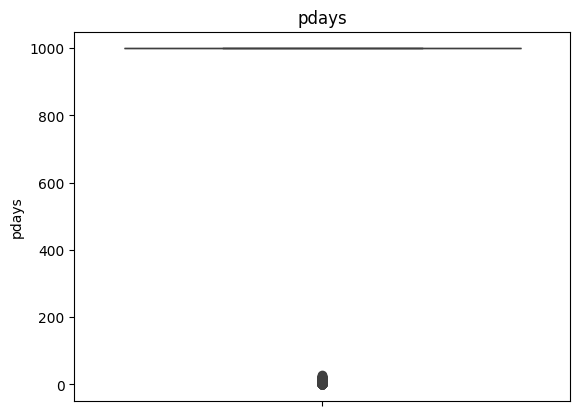

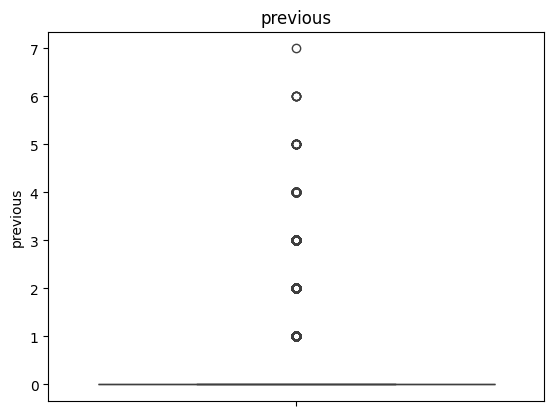

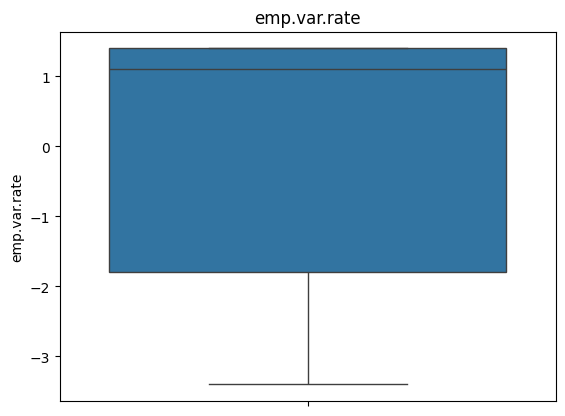

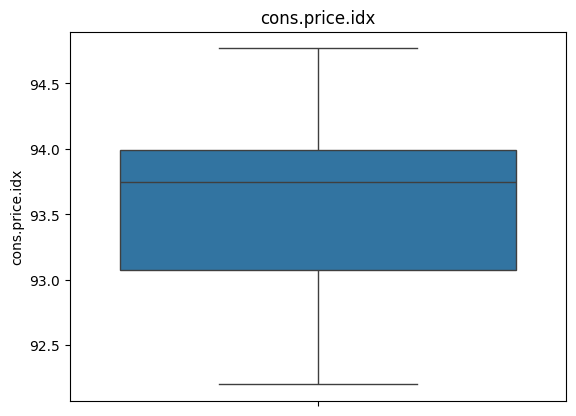

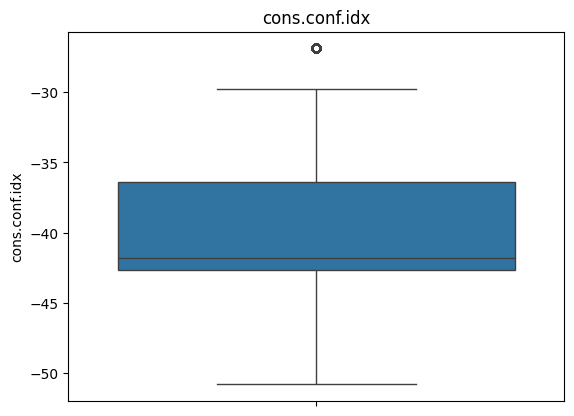

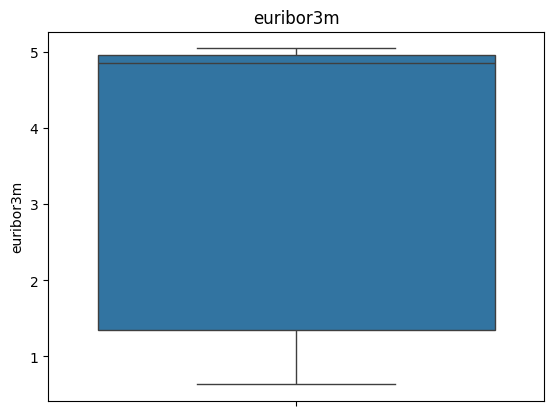

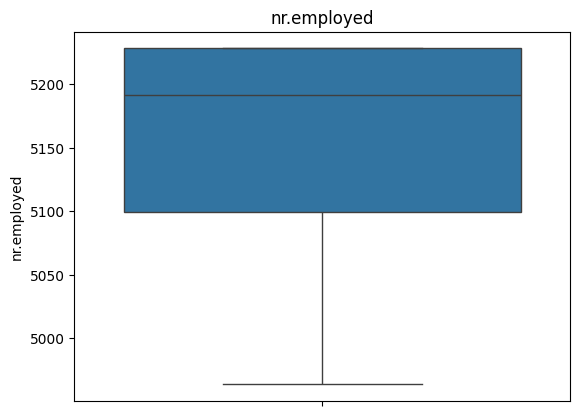

In [36]:
#Outlier Detection
plt.figure(figsize=(10,10))
plt.suptitle("Distribution of Outliers")
for i in df2.columns:
   if((df2[i].dtype == 'int64') | (df2[i].dtype == 'float64')):
    # Set the title of the plot
    plt.title(i)
    sns.boxplot(df2[i])
    plt.show()

In [ ]:
#duration and campaign shows significant number of outliers

In [37]:
# Calculating the interquartile range (IQR) of the column 'duration' in the dataframe df2
# 25th percentile value
q25 = np.percentile(df2['duration'], 25)

# 75th percentile value
q75 = np.percentile(df2['duration'], 75)

# Interquartile range
iqr = q75 - q25

# Calculating the cutoff value using 1.5 times the IQR
cutoff = 1.5 * iqr
# Calculating the lower limit using the 25th percentile value minus the cutoff value
lower = q25 - cutoff
# Calculating the upper limit using the 75th percentile value plus the cutoff value
upper = q75 + cutoff

In [38]:
# Printing the lower and upper limits
print(f'The Lower Limit is : {lower}, The Upper Limit is : {upper}')

The Lower Limit is : -223.5, The Upper Limit is : 644.5


In [39]:
print('The Number of Above Upper Limits :' ,len(df2[df2['duration'] > upper]))
print('The Number of Below Lower Limits :' ,len(df2[df2['duration'] < lower]))

The Number of Above Upper Limits : 2963
The Number of Below Lower Limits : 0


In [40]:
# Removing the outliers
outliers = df2[(df2['duration'] > upper)]
df2.drop(outliers.index, inplace=True)

# Print the new shape of the DataFrame
print("New Shape: ", df2.shape)

New Shape:  (38213, 21)


<ipython-input-40-c6d2d79785fb>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop(outliers.index, inplace=True)


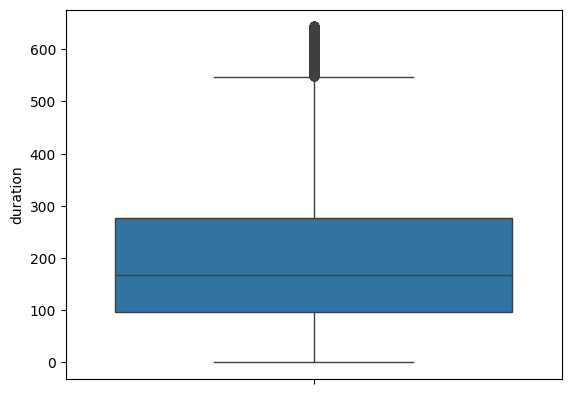

In [41]:
sns.boxplot(df2['duration'])
plt.show()

In [42]:
df3=df2.copy()

In [43]:
# Calculating the interquartile range (IQR) of the column 'campaign' in the dataframe df2
 #25th percentile value
q25 = np.percentile(df3['campaign'], 25)

# 75th percentile value
q75 = np.percentile(df3['campaign'], 75)

# Interquartile range
iqr = q75 - q25

# Calculating the cutoff value using 1.5 times the IQR
cutoff = 1.5 * iqr
# Calculating the lower limit using the 25th percentile value minus the cutoff value
lower = q25 - cutoff
# Calculating the upper limit using the 75th percentile value plus the cutoff value
upper = q75 + cutoff

In [44]:
# Printing the lower and upper limits
print(f'The Lower Limit is : {lower}, The Upper Limit is : {upper}')

The Lower Limit is : -2.0, The Upper Limit is : 6.0


In [45]:
print('The Number of Above Upper Limits :' ,len(df3[df3['campaign'] > upper]))
print('The Number of Below Lower Limits :' ,len(df3[df3['campaign'] < lower]))

The Number of Above Upper Limits : 2262
The Number of Below Lower Limits : 0


In [46]:
# Removing the outliers
outliers = df3[(df3['campaign'] > upper)]
df3.drop(outliers.index, inplace=True)

# Print the new shape of the DataFrame
print("New Shape: ", df3.shape)

New Shape:  (35951, 21)


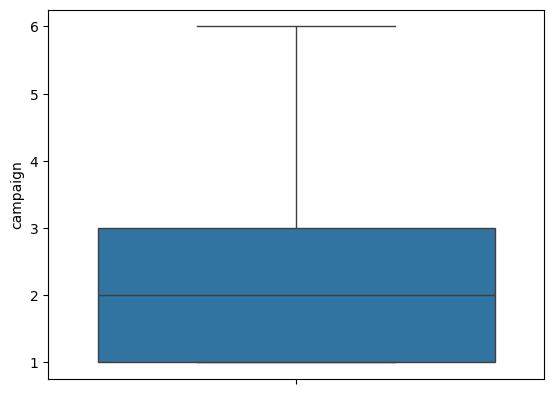

In [47]:
sns.boxplot(df3['campaign'])
plt.show()

In [48]:
for i in df3.columns:
  if(df2[i].dtypes == 'object'):
    print(i)
    print(df2[i].nunique())

job
12
marital
4
education
8
default
3
housing
3
loan
3
contact
2
month
10
day_of_week
5
poutcome
3
y
2


In [49]:
df3.shape

(35951, 21)

In [ ]:
#Label Encoding to make the object columns suitable for modelling

In [50]:
label = LabelEncoder()
for col in df3.select_dtypes(include=['object']).columns:
    df3[col] = label.fit_transform(df3[col])

In [51]:
df_mod=df3.drop(['y'],axis=1)
y=df3['y']

In [52]:
# Identify numerical and categorical columns in the updated df_mod
num_columns = df_mod.select_dtypes(include=['int64','float64']).columns
cat_columns_mod = df_mod.select_dtypes(include=['object']).columns


In [53]:
# Standard Scaling the numerical columns
from sklearn.preprocessing import StandardScaler
stdsclr=StandardScaler()
X_num = df_mod[num_columns] # holds numerical dataframe
X_num_scaled = stdsclr.fit_transform(X_num)
X_num_scaled = pd.DataFrame(X_num_scaled, columns=num_columns, index=df_mod.index) # scaled numerical data

In [54]:
X_num_scaled.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1.526574,-0.201016,-0.282605,-1.754813,-0.509622,-1.091112,-0.451995,1.331593,0.743284,-0.720887,0.384781,-0.81135,0.198055,-0.358495,0.20049,0.672423,0.744503,0.869812,0.733016,0.356403
1,1.622241,0.911686,-0.282605,-0.349219,1.960239,-1.091112,-0.451995,1.331593,0.743284,-0.720887,-0.415039,-0.81135,0.198055,-0.358495,0.20049,0.672423,0.744503,0.869812,0.733016,0.356403
2,-0.291099,0.911686,-0.282605,-0.349219,-0.509622,0.939249,-0.451995,1.331593,0.743284,-0.720887,0.134838,-0.81135,0.198055,-0.358495,0.20049,0.672423,0.744503,0.869812,0.733016,0.356403
3,-0.004098,-1.035542,-0.282605,-1.286282,-0.509622,-1.091112,-0.451995,1.331593,0.743284,-0.720887,-0.400756,-0.81135,0.198055,-0.358495,0.20049,0.672423,0.744503,0.869812,0.733016,0.356403
4,1.526574,0.911686,-0.282605,-0.349219,-0.509622,-1.091112,2.314376,1.331593,0.743284,-0.720887,0.713279,-0.81135,0.198055,-0.358495,0.20049,0.672423,0.744503,0.869812,0.733016,0.356403


In [55]:
X_cat=df_mod[cat_columns_mod]

In [56]:
X=pd.concat([X_num_scaled,X_cat],axis=1)


In [57]:
X.shape

(35951, 20)

In [58]:
y.shape

(35951,)

In [ ]:
#On viewing the output variable 'y',as it is imbalanced("0" output exceeds the "1" output balancing techniques needs to be adopted to improve the precision in analysis)

In [ ]:
#SMOTE technique is adopted

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss


In [ ]:
# Resampling the minority class. The strategy can be changed as required.
smk = SMOTE(random_state=42)
X_res,y_res=smk.fit_resample(X,y)


In [ ]:
oversampled_smk = pd.concat([pd.DataFrame(y_res), pd.DataFrame(X_res)], axis=1)

In [ ]:
oversampled_smk.shape

(65760, 21)

In [ ]:
oversampled_smk.head()

,y,age,job,marital,education,default,housing,loan,contact,month,...,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,0,1.526574,-0.201016,-0.282605,-1.754813,-0.509622,-1.091112,-0.451995,1.331593,0.743284,...,0.384781,-0.81135,0.198055,-0.358495,0.20049,0.672423,0.744503,0.869812,0.733016,0.356403
1,0,1.622241,0.911686,-0.282605,-0.349219,1.960239,-1.091112,-0.451995,1.331593,0.743284,...,-0.415039,-0.81135,0.198055,-0.358495,0.20049,0.672423,0.744503,0.869812,0.733016,0.356403
2,0,-0.291099,0.911686,-0.282605,-0.349219,-0.509622,0.939249,-0.451995,1.331593,0.743284,...,0.134838,-0.81135,0.198055,-0.358495,0.20049,0.672423,0.744503,0.869812,0.733016,0.356403
3,0,-0.004098,-1.035542,-0.282605,-1.286282,-0.509622,-1.091112,-0.451995,1.331593,0.743284,...,-0.400756,-0.81135,0.198055,-0.358495,0.20049,0.672423,0.744503,0.869812,0.733016,0.356403
4,0,1.526574,0.911686,-0.282605,-0.349219,-0.509622,-1.091112,2.314376,1.331593,0.743284,...,0.713279,-0.81135,0.198055,-0.358495,0.20049,0.672423,0.744503,0.869812,0.733016,0.356403


In [ ]:
from collections import Counter
print('Original dataset shape {}'.format(Counter(y)))
print('Resampled dataset shape {}'.format(Counter(y_res)))


Original dataset shape Counter({0: 32880, 1: 3071})
Resampled dataset shape Counter({0: 32880, 1: 32880})


In [ ]:
#Data Modelling

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_res,y_res,test_size=0.3,random_state=42)


In [ ]:
X_train.shape

(46032, 20)

In [ ]:
X_test.shape

(19728, 20)

In [ ]:
#Logistic Regression Analysis

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression()

In [ ]:
model_reg=log_reg.fit(X_train,y_train)
y_pred=model_reg.predict(X_test)
from sklearn.metrics import confusion_matrix,precision_score,classification_report,recall_score,f1_score,accuracy_score
print("Accuracy score on Logistic Regression is:",accuracy_score(y_test,y_pred))

Accuracy score on Logistic Regression is: 0.8705393349553934


In [ ]:
print(confusion_matrix(y_test,y_pred))
print("Precision score on Logistic Regression is:",precision_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

[[8387 1443]
 [1111 8787]]
Precision score on Logistic Regression is: 0.8589442815249266
0.8731120826709062


In [ ]:
y_pred

array([0, 0, 1, ..., 1, 0, 1])

In [ ]:
results_df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
print(results_df)

       Actual  Predicted
18094       0          0
3978        0          0
51643       1          1
61992       1          1
20200       0          0
...       ...        ...
710         0          0
317         0          0
52798       1          1
7155        0          0
36529       1          1

[19728 rows x 2 columns]


In [ ]:
#kNN Classification

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
metric_k=[]
neighbors=np.arange(3,15)
for k in neighbors:
  knn=KNeighborsClassifier(n_neighbors=k)
model_knn=knn.fit(X_train,y_train)

In [ ]:
y_pred_knn=model_knn.predict(X_test)

In [ ]:
y_pred_knn

array([0, 0, 1, ..., 1, 0, 1])

In [ ]:
# finding different accuracies for k values
metric_k=[]
neighbors=range(3,18)

for k in neighbors:
    model1=KNeighborsClassifier(n_neighbors=k)
    model1=model1.fit(X_train,y_train)
    y_pred_knn=model1.predict(X_test)
    acc=accuracy_score(y_test,y_pred_knn)
    metric_k.append(acc)

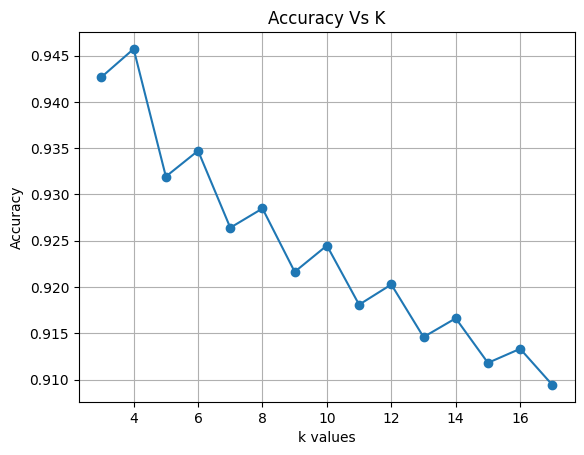

In [ ]:
plt.plot(neighbors,metric_k,'o-')
plt.title('Accuracy Vs K')
plt.xlabel('k values')
plt.ylabel('Accuracy');
plt.grid();
plt.show()

In [ ]:
knn_opt=KNeighborsClassifier(n_neighbors=4)

In [ ]:
knn_opt=knn_opt.fit(X_train,y_train)
y_pred_knn_opt=knn_opt.predict(X_test)

In [ ]:
y_pred_knn_opt

array([0, 0, 1, ..., 1, 0, 1])

In [ ]:
print("Accuracy score on KNN model is:",accuracy_score(y_test,y_pred_knn_opt))
print("Precision score on KNN model is:",precision_score(y_test,y_pred_knn_opt))


Accuracy score on KNN model is: 0.9457116788321168
Precision score on KNN model is: 0.9059137312609216


In [ ]:
results_df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred_knn_opt})
print(results_df)

       Actual  Predicted
18094       0          0
3978        0          0
51643       1          1
61992       1          1
20200       0          0
...       ...        ...
710         0          0
317         0          0
52798       1          1
7155        0          0
36529       1          1

[19728 rows x 2 columns]


In [ ]:
print(confusion_matrix(y_test,y_pred_knn))
print(f1_score(y_test,y_pred_knn))

[[ 8790  1685]
 [  144 10441]]
0.919466337897935


In [ ]:
#Support Vector Classifier SVC
from sklearn.svm import SVC
svm_clf=SVC(kernel='linear')
svm_model=svm_clf.fit(X_train,y_train)
y_pred_svc=svm_clf.predict(X_test)


In [ ]:
print("Accuracy score on SV classification model is:",accuracy_score(y_test,y_pred_svc))
print("Precision score on SV classification model is:",precision_score(y_test,y_pred_svc))

Accuracy score on SV classification model is: 0.8772554605887939
Precision score on SV classification model is: 0.8515556336790298


In [ ]:
results_df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred_svc})
print(results_df)

       Actual  Predicted
56114       1          1
53045       1          1
24032       0          0
20399       0          0
13774       0          0
...       ...        ...
21449       0          0
64590       1          1
64135       1          1
66913       1          1
34449       0          1

[21060 rows x 2 columns]


In [ ]:
#Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_clf=DecisionTreeClassifier()
dt_clf.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_dt=dt_clf.predict(X_test)

In [ ]:
print("Accuracy score on Decision Tree classification model is:",accuracy_score(y_test,y_pred_dt))
print("Precision score on Decision Tree classification model is:",precision_score(y_test,y_pred_dt))


Accuracy score on Decision Tree classification model is: 0.9388179237631792
Precision score on Decision Tree classification model is: 0.9334663341645886


In [ ]:
print(confusion_matrix(y_test,y_pred_dt))
print(f1_score(y_test,y_pred_dt))

[[9163  667]
 [ 540 9358]]
0.9394167545048436


In [ ]:
results_df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred_dt})
print(results_df)

       Actual  Predicted
18094       0          0
3978        0          0
51643       1          1
61992       1          1
20200       0          0
...       ...        ...
710         0          0
317         0          0
52798       1          1
7155        0          0
36529       1          1

[19728 rows x 2 columns]


In [ ]:
#Random Forest Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_clf=RandomForestClassifier()
rf_clf.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred_rf=rf_clf.predict(X_test)

In [ ]:
print("Accuracy score on RandomForestClassifier classification model is:",accuracy_score(y_test,y_pred_rf))
print("Precision score on RandomForestClassifier classification model is:",precision_score(y_test,y_pred_rf))


Accuracy score on RandomForestClassifier classification model is: 0.9661901865369019
Precision score on RandomForestClassifier classification model is: 0.9524556416037644


In [ ]:
print(confusion_matrix(y_test,y_pred_rf))
print(f1_score(y_test,y_pred_rf))

[[9345  485]
 [ 182 9716]]
0.9668142693666352


In [ ]:
results_rf=pd.DataFrame({'Actual':y_test,'Predicted':y_pred_rf})
print(results_rf)

       Actual  Predicted
18094       0          0
3978        0          0
51643       1          1
61992       1          1
20200       0          0
...       ...        ...
710         0          0
317         0          0
52798       1          1
7155        0          0
36529       1          1

[19728 rows x 2 columns]


In [ ]:
#Random Forest Classification Model gives the best results on accuracy and precision and can be opted as the best model for prediction.
